In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 1.1 Just do one big experiment

In [266]:
# function for calculating pi through Monte Carlo methode (using only top right quarter of circle/square)
def single_pi_calculator(n):
    x = np.zeros(n)
    y = np.zeros(n)
    radii = np.zeros(n)
    for i in range(n):
        x[i] = random.random()
        y[i] = random.random()
    radii = np.sqrt(x**2 + y**2)
    inside_the_circle = (radii <= 1)
    pi_estimate = 4 * inside_the_circle.sum() / n
    return(pi_estimate, inside_the_circle.sum(), radii)
    

In [267]:
#Compute the mean and the standard deviation of pi for 10000 pairs in 1 experiment

pairs = 10000
pi_mean, points_in_circle, radii = single_pi_calculator(pairs)
#pi_mean, inside_the_circle, radii = pi_calculator(10000)
print('The mean of the pi observable is:', pi_mean, '.')
print('There is only one experiment, so the mean of the observable becomes the final answer giving us 0 as the standard deviation for pi.')

The mean of the pi observable is: 3.1572 .
There is only one experiment, so the mean of the observable becomes the final answer giving us 0 as the standard deviation for pi.


There is another possibility for estimating the uncertainty. We can treat each pair as its own estimation of pi (4 or 0). 

In [268]:
sigma_pi = np.sqrt(4*points_in_circle/(pairs-1))
print('We find pi =', pi_mean, '+/-', sigma_pi, '.')

We find pi = 3.1572 +/- 1.7769399966164185 .


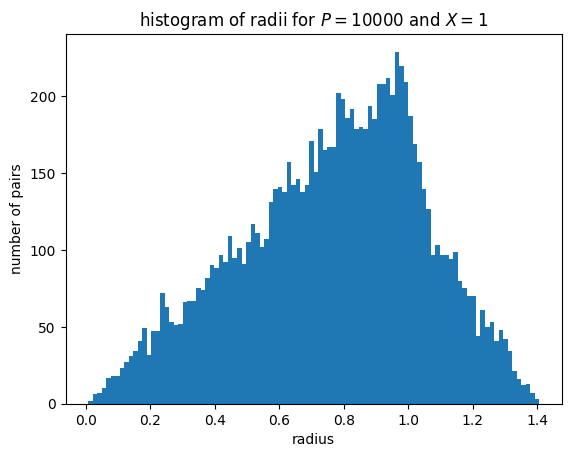

In [269]:
#histogram of radii

plt.hist(radii, bins=100)
plt.title('histogram of radii for $P = 10000$ and $X = 1$')
plt.xlabel('radius')
plt.ylabel('number of pairs')

plt.show()

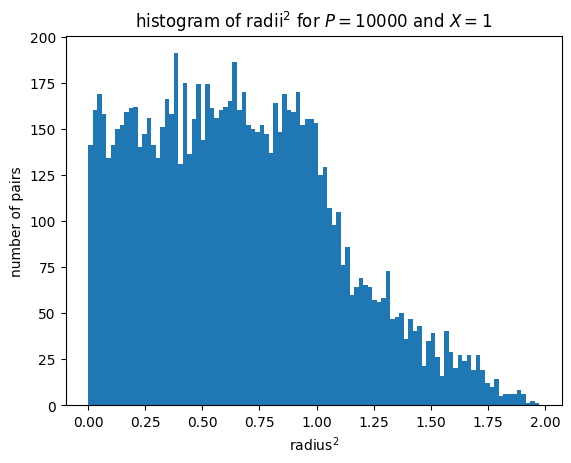

In [270]:
#histogram of radii squared

plt.hist(radii**2, bins = 100)
plt.title('histogram of radii$^{2}$ for $P = 10000$ and $X = 1$')
plt.xlabel('radius$^{2}$')
plt.ylabel('number of pairs')

plt.show()

Explanation: 

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6761/2786999003.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(pi_mean, linestyle = 'dotted', color = 'black', label = 'mean value of $\pi$')
/tmp/ipykernel_6761/2786999003.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.axvspan(pi_mean - sigma_pi, pi_mean + sigma_pi, alpha = 0.8, color = 'moccasin', label = 'standard devation of $\pi$')


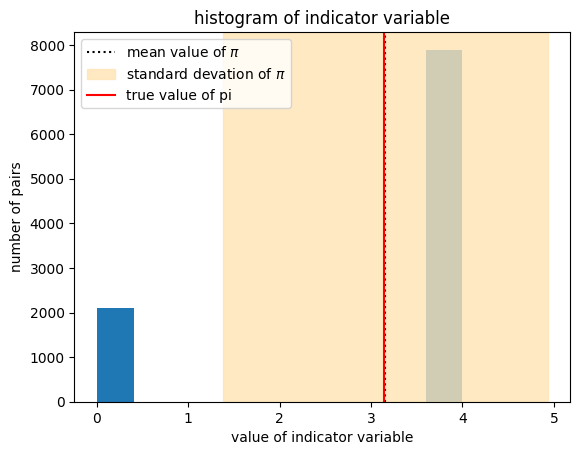

In [271]:
# histogram of indicator variables

indicator_var = 4*(radii <= 1)
plt.hist(indicator_var*1)
plt.axvline(pi_mean, linestyle = 'dotted', color = 'black', label = 'mean value of $\pi$')
plt.axvspan(pi_mean - sigma_pi, pi_mean + sigma_pi, alpha = 0.8, color = 'moccasin', label = 'standard devation of $\pi$')
#plt.axvspan(pi_mean - 10*sigma_pi, pi_mean + 10*sigma_pi, color = 'moccasin', label = 'standard devation of $\pi$') #wrong sigma used!!!!!!!!!!!!!!!!!!!!!!!!!!1
plt.axvline(np.pi, label = 'true value of pi', color = 'red')
plt.title('histogram of indicator variable')
plt.xlabel('value of indicator variable')
plt.ylabel('number of pairs')
plt.legend()

plt.show()

# 1.2 Split into 100

In [272]:
def pi_calculator(pairs, experiments):

    pi_estimate_list = np.zeros(experiments)
    inside_the_circle_list = np.zeros(experiments)
    radii_list = np.zeros((experiments, pairs))

    for k in range(experiments):
        pi_estimate_list[k], inside_the_circle_list[k], radii_list[k, :] =  single_pi_calculator(pairs)

    pi_mean = pi_estimate_list.sum()/experiments
    differences_squared = (pi_estimate_list - pi_estimate_list.sum()/experiments)**2
    pi_sigma = np.sqrt(differences_squared.sum()/(experiments-1))
    

    return(pi_mean, pi_sigma, pi_estimate_list, inside_the_circle_list, radii_list)

In [273]:
# estimate for pi through 100 experiments with 100 pairs each
 
pi_mean_split, pi_sigma_split, pi_estimates_list, inside_the_circle_list, radii_list = pi_calculator(100, 100)
print('We find pi =', pi_mean_split, '+/-', pi_sigma_split)

We find pi = 3.142 +/- 0.1669573223154572


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6761/2846601891.py:2: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(pi_mean_split, linestyle = 'dotted', color = 'black', label = 'mean value of $\pi$')
/tmp/ipykernel_6761/2846601891.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.axvspan(pi_mean_split - pi_sigma_split, pi_mean + pi_sigma_split, color = 'moccasin', label = 'standard devation of $\pi$', alpha = 0.6)


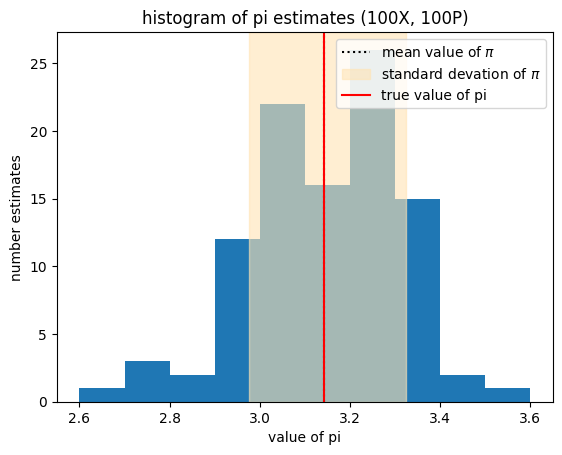

In [274]:
plt.hist(pi_estimates_list)
plt.axvline(pi_mean_split, linestyle = 'dotted', color = 'black', label = 'mean value of $\pi$')
plt.axvspan(pi_mean_split - pi_sigma_split, pi_mean + pi_sigma_split, color = 'moccasin', label = 'standard devation of $\pi$', alpha = 0.6)
plt.axvline(np.pi, label = 'true value of pi', color = 'red')
plt.title('histogram of pi estimates (100X, 100P)')
plt.xlabel('value of pi')
plt.ylabel('number estimates')
plt.legend()

plt.show()

# 1.3 A Zillion little experiments

In [275]:
# estimate for pi through 10000 experiments with 1 pair each

pi_mean_zillion, pi_sigma_zillion, pi_estimates_zillion, inside_the_circle_zillion, radii_zillion = pi_calculator(1, 10000)

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6761/3629330865.py:2: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(pi_mean_zillion, linestyle = 'dotted', color = 'black', label = 'mean value of $\pi$')
/tmp/ipykernel_6761/3629330865.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.axvspan(pi_mean_zillion - pi_sigma_zillion, pi_mean_zillion + pi_sigma_zillion, color = 'moccasin', label = 'standard devation of $\pi$', alpha = 0.6)
/tmp/ipykernel_6761/3629330865.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi, label = 'true value of $\pi$', color = 'red')
/tmp/ipykernel_6761/3629330865.p

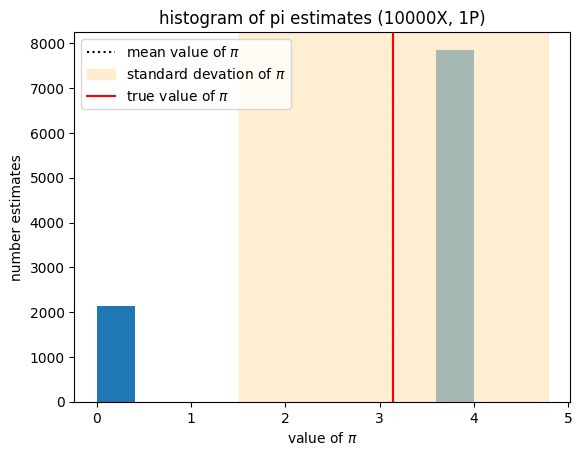

In [276]:
plt.hist(pi_estimates_zillion)
plt.axvline(pi_mean_zillion, linestyle = 'dotted', color = 'black', label = 'mean value of $\pi$')
plt.axvspan(pi_mean_zillion - pi_sigma_zillion, pi_mean_zillion + pi_sigma_zillion, color = 'moccasin', label = 'standard devation of $\pi$', alpha = 0.6)
plt.axvline(np.pi, label = 'true value of $\pi$', color = 'red')
plt.title('histogram of pi estimates (10000X, 1P)')
plt.xlabel('value of $\pi$')
plt.ylabel('number estimates')
plt.legend()

plt.show()

yes obv. this is familiar.
Explaination: 

# 1.4 Stop and think

-yes they are comapatible
-yes i think it makes sense, eventhough i guess the answer kinda wants me to say no
-reorganizing gives us the oppertunity to minimize our uncertainty

# More vs. longer experiments

In [277]:
X = np.array([10, 100, 1000, 10000])
P = np.array([10, 100, 1000, 10000])

pi_means = np.zeros(16)
pi_sigmas = np.zeros(16)
pi_estimates = np.arange((16, 10000))

for k in range(4):
    for l in range(4):
         pi_means[k*4+l], pi_sigmas[k*4+l], pi_estimates[4*k+l], _, _ = pi_calculator(X[k], P[l])


TypeError: arange: scalar arguments expected instead of a tuple.

In [ ]:
pi_means

array([3.2       , 3.216     , 3.136     , 3.14624   , 3.124     ,
       3.124     , 3.13624   , 3.142316  , 3.1448    , 3.14672   ,
       3.139724  , 3.1426476 , 3.14352   , 3.141132  , 3.1412296 ,
       3.14141444])

In [ ]:
pi_estimates.shape

(44440,)

array([3.04     , 3.22     , 3.1368   , 3.1434   , 3.128    , 3.1752   ,
       3.14048  , 3.14292  , 3.128    , 3.14576  , 3.139636 , 3.1421524,
       3.14408  , 3.142604 , 3.1417408, 3.1417602])